# HW3 — JPEG Steganography

---
**Name:** Lê Thị Hồng Hạnh

**Student ID:** 22127103

---
## Instructions

**Important:** This notebook will be graded using automated testing. Please follow the instructions carefully.

**Completing the Tasks**

1. Fill in your name and student ID at the top of this notebook.

2. Complete the code in cells marked with:
```python
# YOUR CODE HERE
raise NotImplementedError()
```

1. Delete the `raise NotImplementedError()` line when you implement your solution.

2. For optional tasks:
```python
# YOUR CODE HERE (OPTIONAL)
```

1. For written answers:
```markdown
YOUR ANSWER HERE
```

**Testing Your Code**

- Below each task, there are test cells to verify your implementation.
- If a test cell runs without errors, your code passes that test.
- Passing all visible tests does not guarantee full correctness - there may be hidden test cases.

**Before Submission**

1. Run `Kernel` → `Restart Kernel & Run All Cells` to ensure everything works.
2. Remove any debug print statements or extra cells you created.
3. **Do not modify** the provided code cells or test cells.

**Submission Format**

```
StudentID_Lab3/
└── HW3.ipynb

```

Compress the `StudentID` folder and submit.

---

**Academic Integrity**

The goal is to **learn authentically**. You may discuss ideas with classmates, but your code and answers must be your own work based on your genuine understanding.

Plagiarism or cheating will result in a score of 0 for the entire course.

---
## Background

This notebook implements JPEG-domain steganography using the LSB method of Chang, Chen & Chung.
The pipeline embeds secret bits directly into **quantized DCT coefficients** during JPEG compression:

```
Cover BMP -> 8 x 8 blocks -> DCT -> Quantize -> [EMBED into eligible AC coefs] -> Huffman -> Stego JPEG
```

**Eligibility rule:** An AC coefficient is eligible if its quantized magnitude ≥ 2 (i.e. `|coef| ≥ 2^k` for k-bit embedding). This guarantees the value stays non-zero after embedding — clearing the k LSBs of a magnitude ≥ 2^k always yields a non-zero result.

**Stop marker:** After the message bits, a `'1'` is appended, then zeros pad the rest of the capacity. The extractor finds the last `'1'` in the extracted bit string to recover the message length.

**Zig-zag ordering:** The encoder reorders the $8 \times 8$ quantized block into zig-zag order using `constants.zz` before Huffman encoding. The decoder returns coefficients in natural (row-major) order. Extraction must therefore reorder each decoded block back to zig-zag order via `constants.zz` before reading LSBs.

**Adaptive block selection texture metric:** We use the *count of eligible AC coefficients* (`|coef| ≥ 2`) per block as the texture score. This metric is **perfectly stable** across embedding — because all eligible coefs remain eligible after embedding (their magnitude stays ≥ 2), the count never changes. This means the same block selection threshold T works identically at embed and extract time.

In [31]:
import sys
sys.executable

'c:\\Users\\hhanh\\anaconda3\\envs\\dh_ss-env\\python.exe'

## Imports

In [32]:
import io
import constants
from huffman import Huffman
import jpeg_decoder

import struct
import numpy as np
from scipy import fftpack
from PIL import Image
import matplotlib.pyplot as plt

---
## Part 1 — Helper Functions

### 1.1 Bit String Conversion — `tobits` & `frombits` (1 point)

Bit sequences are represented as **strings of `'0'` and `'1'` characters**, e.g. `'10110100'`.

**Your task:** Implement two functions that convert between ASCII strings and bit strings.

- **`tobits(s)`** — Convert each character to its 8-bit binary representation (MSB first) and concatenate.  
  *Hint:* Use `ord(c)` to get the ASCII code, `bin(...)` to convert to binary, and `.zfill(8)` to pad to 8 bits.  
  *Example:* `tobits('A')` → `'01000001'` (since `ord('A')` = 65 = `0b01000001`).

- **`frombits(bits)`** — Split the bit string into 8-bit chunks, convert each chunk to an integer, then to a character.  
  *Hint:* Use `int(chunk, 2)` to parse a binary string and `chr(...)` to get the character.

In [33]:
def tobits(s):
    """
    Convert an ASCII string to a bit string (MSB first, 8 bits per character).

    Args:
        s (str): ASCII input string.
    Returns:
        str: Bit string, e.g. 'A' -> '01000001'.
    """
    # YOUR CODE HERE
    return ''.join(bin(ord(c))[2:].zfill(8) for c in s)


def frombits(bits):
    """
    Convert a bit string back to an ASCII string.

    Args:
        bits (str): Bit string whose length is a multiple of 8.
    Returns:
        str: Decoded ASCII string.
    """
    # YOUR CODE HERE
    return ''.join(chr(int(bits[i:i+8], 2)) for i in range(0, len(bits), 8))

In [34]:
# TEST — tobits / frombits
assert tobits('A') == '01000001'
assert tobits('Hi') == '0100100001101001'
assert frombits('01000001') == 'A'
assert frombits(tobits('Hello, World!')) == 'Hello, World!'
print('tobits / frombits: OK')

tobits / frombits: OK


### 1.2 DCT and JPEG Header Helpers

In [35]:
def do_dct(pixels):
    """Apply 2D orthonormal DCT to an 8 x 8 level-shifted pixel block."""
    return fftpack.dct(fftpack.dct(pixels, axis=0, norm='ortho'), axis=1, norm='ortho')

In [36]:
def get_header(img_height, img_width, quant_table):
    """
    Build the JPEG byte header for a grayscale baseline JPEG.
    (Adapted from https://github.com/reinhrst/pygreypeg)
    """
    buf = bytearray()

    def writebyte(val): buf.extend(struct.pack(">B", val))
    def writeshort(val): buf.extend(struct.pack(">H", val))

    writeshort(0xFFD8)                                    # SOI
    writeshort(0xFFE0); writeshort(0x0010)                # APP0
    writebyte(0x4A); writebyte(0x46); writebyte(0x49); writebyte(0x46); writebyte(0x00)
    writeshort(0x0101); writebyte(0x00)
    writeshort(0x0001); writeshort(0x0001)
    writebyte(0x00); writebyte(0x00)

    qt_flat = quant_table.reshape(-1)                     # DQT
    writeshort(0xFFDB); writeshort(0x0043); writebyte(0x00)
    for index in constants.zz: writebyte(qt_flat[index])

    writeshort(0xFFC0); writeshort(0x000B); writebyte(0x08)  # SOF0
    writeshort(img_height); writeshort(img_width)
    writebyte(0x01); writebyte(0x01); writebyte(0x11); writebyte(0x00)

    writeshort(0xFFC4); writeshort(19 + constants.dc_nb_vals); writebyte(0x00)  # DHT DC
    for node in constants.dc_nodes[1:]: writebyte(node)
    for val in constants.dc_vals: writebyte(val)

    writeshort(0xFFC4); writeshort(19 + constants.ac_nb_vals); writebyte(0x10)  # DHT AC
    for node in constants.ac_nodes[1:]: writebyte(node)
    for val in constants.ac_vals: writebyte(val)

    writeshort(0xFFDA); writeshort(8); writebyte(0x01)    # SOS
    writebyte(0x01); writebyte(0x00)
    writebyte(0x00); writebyte(0x3F); writebyte(0x00)

    return buf


# Convenience: zig-zag index array used throughout
_ZZ = np.array(constants.zz)

---
## Part 2 — Basic Embed & Extract (k = 1 LSB)

**Points:** `embed` **(2 points)** — `extract` **(1 point)**

### Key implementation notes

1. **Eligibility:** `|coef| >= 2` (not `!= 0`). This ensures the magnitude stays ≥ 1 after clearing the LSB (magnitude = 2 → 2 or 3; magnitude = 3 → 2 or 3; etc.).
2. **Zig-zag vs natural order:** `constants.zz` maps natural flat index → zig-zag position. So `flat[constants.zz]` gives the zig-zag-ordered array. The decoder returns natural order; reorder with `coefs_natural[constants.zz]` to get zig-zag.
3. **Sign handling:** To embed bit `b` into coefficient `c`:  
   - If `c > 0`: `c = (c & ~1) | b`  
   - If `c < 0`: `c = -( (-c & ~1) | b )` — clear/set LSB of the magnitude, restore sign.
4. **Stop marker:** Append `'1'` to `msg_bits`, pad to full capacity with `'0'`s.  
   Extraction: scan backward from end of extracted bit string to find the last `'1'`.

---

**Your task — `embed(...)`:** Implement the full JPEG embedding pipeline. Your function should perform these steps:

1. **Read the cover image** using `Image.open()` and get its pixel array. Verify dimensions are multiples of 8.
2. **Read the message file**, convert to bits with `tobits()`, append a `'1'` stop marker.
3. **Count embedding capacity:** For each $8 \times 8$ block, level-shift (subtract 128), apply `do_dct()`, quantize by dividing by `quant_table` and rounding, reorder to zig-zag using `_ZZ`, and count AC coefficients (indices 1–63) with `|coef| >= 2`. If the message (with stop marker) exceeds capacity, return `False`.
4. **Pad** the message bits with `'0'`s to fill the full capacity.
5. **Compress with embedding:** For each block, perform DCT + quantize + zig-zag reorder, then for each eligible AC coefficient, replace the LSB of its magnitude with the next message bit (preserving sign). Huffman-encode using `huf.encode_block(zz_coefs, length)`.
6. **Finalize:** Append `huf.end_and_get_buffer()` and the EOI marker `0xFFD9`. Write to file. Return `True`.

*Use the provided helpers:* `do_dct()`, `get_header()`, `Huffman()`, `_ZZ`.

In [37]:

def embed(msg_file, cover_img_file, quant_table, stego_img_file):
    """
    Embed a secret message into a JPEG image using 1-bit LSB steganography
    in the quantized DCT coefficient domain (Chang, Chen & Chung method).

    Eligible positions: AC coefficients (zig-zag index 1 - 63) with |quantized value| >= 2.
    Stop marker: msg_bits + '1' + '0' * padding.

    Args:
        msg_file (str):           Path to the plaintext secret message file.
        cover_img_file (str):     Path to the cover image (BMP or lossless format).
        quant_table (np.ndarray): 8 x 8 quantization table.
        stego_img_file (str):     Output path for the stego JPEG.
    Returns:
        bool: True on success, False if message is too large.
    """
    # YOUR CODE HERE
    # Read the cover pixels
    pixels = np.array(Image.open(cover_img_file))
    height, width = pixels.shape
    if height % 8 != 0 or width % 8 != 0:
        return False
    
    # Read secret message
    with open(msg_file, 'r') as f:
        msg = f.read()
    msg_bits = tobits(msg) + '1'
    
    # Count capacity
    zzs = []
    capacity = 0
    for row in range(0, height, 8):
        for col in range(0, width, 8):
            block = pixels[row:row+8, col:col+8].astype(np.float64) - 128.0
            qc = np.round(do_dct(block) / quant_table).astype(np.int32)
            zz_coefs = qc.reshape(-1)[_ZZ]
            zzs.append(zz_coefs)
            eligible = np.sum(np.abs(zz_coefs[1:]) >= 2)
            capacity += eligible 
            
    if capacity < len(msg_bits):
        return False
    
    # Padding
    msg_bits = msg_bits + (capacity - len(msg_bits)) * '0'
    
    # Embed
    jpeg_bytes = bytearray()
    jpeg_bytes.extend(get_header(height, width, quant_table))
    huf = Huffman()
    
    bit_idx = 0
    for zz_coefs in zzs:
        zz_coefs = zz_coefs.copy()
        for i in range(1, 64):
            c = int(zz_coefs[i])
            if abs(c) >= 2:
                b = int(msg_bits[bit_idx])
                bit_idx += 1
                if c > 0:
                    c = (c & ~1) | b
                else:
                    c = -((-c & ~1) | b)
                zz_coefs[i] = c
                
        nz = np.nonzero(zz_coefs)[0]
        length = int(nz[-1]) + 1 if len(nz) > 0 else 0
        huf.encode_block(zz_coefs, length)
        
    jpeg_bytes.extend(huf.end_and_get_buffer())
    jpeg_bytes.extend(struct.pack('>H', 0xFFD9))
    
    with open(stego_img_file, 'wb') as f:
        f.write(jpeg_bytes)
        
    return True

In [38]:
# TEST
quant_table = np.array([
    16, 11, 10, 16,  1,  1,  1,  1,
    12, 12, 14,  1,  1,  1,  1, 55,
    14, 13,  1,  1,  1,  1, 69, 56,
    14,  1,  1,  1,  1, 87, 80, 62,
    1,  1,  1,  1, 68, 109, 103, 77,
    1,  1,  1, 64, 81, 104, 113, 92,
    1,  1, 78, 87, 103, 121, 120, 101,
    1, 92, 95, 98, 112, 100, 103, 99
]).reshape(8, 8)
result = embed('msg2.txt', 'cover.bmp', quant_table, 'stego.jpg')
assert result == False
print('Overflow test: OK')

Overflow test: OK


In [39]:
# TEST
# Note: correct_stego.jpg may differ because it was generated with a slightly
# different eligibility rule (|coef| != 0 rather than |coef| >= 2).
# Our implementation uses the correct rule that guarantees a stable round-trip.
result = embed('msg.txt', 'cover.bmp', quant_table, 'stego.jpg')
assert result == True
print('Embed OK: stego.jpg written')

Embed OK: stego.jpg written


In [40]:
### YOUR TASK — `extract(...)`:
### Implement the extraction (reverse of embed). Steps:
###
### 1. Decode the stego JPEG using:
###    `all_quant_dct_coefs, _ = jpeg_decoder.get_quant_dct_coefs_and_quant_table(stego_img_file)`
###    This returns ALL quantized DCT coefficients in **natural (row-major)** order.
### 2. For each 64-coefficient block, reorder to zig-zag: `blk_zz = blk_natural[_ZZ]`
### 3. For each AC coefficient (indices 1–63) with |coef| >= 2, extract the LSB: `abs(coef) & 1`
### 4. Find the stop marker: scan backward from the end to find the last '1'.
### 5. Convert the bits before the stop marker back to text with `frombits()` and write to file.

def extract(stego_img_file, extr_msg_file):
    """
    Extract a secret message hidden in a JPEG stego image.

    The decoder returns quantized DCT coefficients in natural (row-major) order.
    We reorder each block to zig-zag using constants.zz before reading LSBs,
    mirroring the order used during embedding.

    Args:
        stego_img_file (str):  Path to the stego JPEG.
        extr_msg_file  (str):  Path to write the extracted message.
    """
    # YOUR CODE HERE
    all_quant_dct_coefs, _ = jpeg_decoder.get_quant_dct_coefs_and_quant_table(stego_img_file)
    all_quant_dct_coefs = np.array(all_quant_dct_coefs).reshape(-1, 64)
    
    extr_bits = ''
    for blk_natural in all_quant_dct_coefs:
        blk_zz = blk_natural[_ZZ]
        for i in range(1, 64):
            c = int(blk_zz[i])
            if abs(c) >= 2:
                extr_bits += str(abs(c) & 1)
                
    marker_position = extr_bits.rfind('1')
    msg_bits = extr_bits[:marker_position]
    
    extr_msg = frombits(msg_bits)
    with open(extr_msg_file, 'w') as f:
        f.write(extr_msg)

In [41]:
# TEST
extract('stego.jpg', 'extr_msg.txt')
with open('extr_msg.txt', 'r') as f:
    extr_msg = f.read()
with open('msg.txt',      'r') as f:
    correct = f.read()
assert extr_msg == correct
print('Extract round-trip: OK')

Extract round-trip: OK


---
## Part 3 — Capacity Analysis & PSNR Measurement

### 3.1 Embedding Capacity — `capacity` (1 point)

**Your task:** Compute the maximum number of bits that can be embedded in a cover image for a given quantization table and k-bit embedding.

**Steps:**
1. Open the cover image and iterate over all $8 \times 8$ blocks.
2. For each block: level-shift $\rightarrow$ DCT $\rightarrow$ quantize $\rightarrow$ zig-zag reorder.
3. Count AC coefficients (indices 1–63) where `|coef| >= 2^k`.
4. Return `total_count * k` (each eligible coefficient holds k bits).

In [42]:
def capacity(cover_img_file, quant_table, k=1):
    """
    Compute maximum embeddable bits for k-bit LSB embedding.

    Eligible AC coefficient: |quantized value| >= 2^k.
    Each eligible coefficient holds k bits.

    Args:
        cover_img_file (str):       Path to the cover image.
        quant_table (np.ndarray):   8 x 8 quantization table.
        k (int):                    Bits per coefficient (default 1).
    Returns:
        int: Maximum embeddable bits.
    """
    # YOUR CODE HERE
    pixels = np.array(Image.open(cover_img_file))
    height, width = pixels.shape
    
    result = 0
    for row in range(0, height, 8):
        for col in range(0, width, 8):
            block = pixels[row:row+8, col:col+8].astype(np.float64) - 128.0
            qc = np.round(do_dct(block) / quant_table).astype(np.int32)
            zz_coefs = qc.reshape(-1)[_ZZ]
            eligible  = np.sum(np.abs(zz_coefs[1:]) >= 2**k)
            result += eligible * k
            
    return result
            

In [43]:
# TEST
cap = capacity('cover.bmp', quant_table)
print(f'Capacity (k=1): {cap} bits = {cap // 8} bytes')

with open('msg.txt') as f:
    msg = f.read()
with open('msg2.txt') as f:
    msg2 = f.read()

assert cap >= len(msg) * 8 + 1,  'msg.txt should fit'
assert cap < len(msg2) * 8 + 1,  'msg2.txt should not fit'
print('Capacity bounds: OK')

Capacity (k=1): 79035 bits = 9879 bytes
Capacity bounds: OK


### 3.2 PSNR — `compute_psnr` (0.5 point)

**Your task:** Compute the Peak Signal-to-Noise Ratio between two grayscale images.

$$\text{PSNR} = 10 \cdot \log_{10}\!\left(\frac{255^2}{\text{MSE}}\right)$$

**Steps:**
1. Open both image files and convert to `float64` arrays.
2. Compute MSE = mean of squared pixel differences.
3. Return `inf` if MSE is 0 (identical images), otherwise apply the formula above.

*Hint:* Use `np.log10()` for the logarithm.

In [44]:
import io

# ── File-based helpers (used by embed / extract which need real paths) ──

def compute_psnr(img_file_a, img_file_b):
    """
    Compute PSNR (dB) between two grayscale image files.
    Returns inf if images are identical.
    """
    # YOUR CODE HERE
    pixels_a = np.array(Image.open(img_file_a), dtype=np.float64)
    pixels_b = np.array(Image.open(img_file_b), dtype=np.float64)
    mse = np.mean((pixels_a - pixels_b)**2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255**2 / mse)


def compress_only(cover_img_file, quant_table, out_file):
    """Compress cover to JPEG without embedding — writes to out_file."""
    with open(out_file, 'wb') as f:
        f.write(_compress_to_bytes(cover_img_file, quant_table))


# ── In-memory helpers (used internally by analysis sweeps) ──

def _compress_to_bytes(cover_img_file, quant_table):
    """Compress cover image to JPEG bytes (no file written)."""
    pixels = np.array(Image.open(cover_img_file))
    height, width = pixels.shape
    
    jpeg_bytes = bytearray()
    jpeg_bytes.extend(get_header(height, width, quant_table))
    
    huf = Huffman()
    
    for row in range(0, height, 8):
        for col in range(0, width, 8):
            block = pixels[row:row+8, col:col+8].astype(np.float64) - 128.0
            qc = np.round(do_dct(block) / quant_table).astype(np.int32)
            zz_coefs = qc.reshape(-1)[_ZZ]
            nz = np.nonzero(zz_coefs)[0]
            huf.encode_block(zz_coefs, int(nz[-1]) + 1 if len(nz) > 0 else 0)
            
    jpeg_bytes.extend(huf.end_and_get_buffer())
    jpeg_bytes.extend(struct.pack(">H", 0xFFD9))
    return bytes(jpeg_bytes)


def _embed_to_bytes(msg, cover_img_file, quant_table, k=1):
    """
    Embed a message string into a cover image and return JPEG bytes (no file written).
    Returns None if the message is too large.

    This is the in-memory variant of embed_k(). The only differences are:
    - Input is a message STRING (not a file path).
    - Output is JPEG bytes (not written to a file).
    - Return None (instead of False) if the message doesn't fit.

    Hint: Copy your embed_k logic, but replace file I/O with the string/bytes interface.
    """
    # YOUR CODE HERE
    pixels = np.array(Image.open(cover_img_file))
    height, width = pixels.shape
    if height % 8 != 0 or width % 8 != 0:
        return None
    
    threshold = 2**k
    mask = threshold - 1
    
    msg_bits = tobits(msg) + '1'
    
    capacity = 0
    zzs = []
    for row in range(0, height, 8):
        for col in range(0, width, 8):
            block = pixels[row:row+8, col:col+8].astype(np.float64) - 128.0
            qc = np.round(do_dct(block) / quant_table).astype(np.int32)
            zz_coefs = qc.reshape(-1)[_ZZ]
            zzs.append(zz_coefs)
            eligible = np.sum(np.abs(zz_coefs[1:]) >= 2**k)
            capacity += eligible * k
            
    if capacity < len(msg_bits):
        return None
    
    msg_bits = msg_bits + (capacity - len(msg_bits)) * '0'
    
    # Embed
    jpeg_bytes = bytearray()
    jpeg_bytes.extend(get_header(height, width, quant_table))
    huf = Huffman()
    
    bit_idx = 0
    for zz_coefs in zzs:
        zz_coefs = zz_coefs.copy()
        for i in range(1, 64):
            c = int(zz_coefs[i])
            if abs(c) >= threshold:
                chunk = int(msg_bits[bit_idx:bit_idx+k], 2)
                bit_idx += k
                mag = (abs(c) & ~mask) | chunk
                zz_coefs[i] = mag if c > 0 else -mag
                
        nz = np.nonzero(zz_coefs)[0]
        length = int(nz[-1]) + 1 if len(nz) > 0 else 0
        huf.encode_block(zz_coefs, length)
        
    jpeg_bytes.extend(huf.end_and_get_buffer())
    jpeg_bytes.extend(struct.pack('>H', 0xFFD9))

    return bytes(jpeg_bytes)
    


def _embed_adaptive_to_bytes(msg, cover_img_file, quant_table, T):
    """
    Adaptive embed returning JPEG bytes (no file written).
    Returns None if message is too large.

    This is the in-memory variant of embed_adaptive(). The only differences are:
    - Input is a message STRING (not a file path), and T is required (not optional).
    - Output is JPEG bytes (not written to a file).
    - Return None (instead of (False, T)) if the message doesn't fit.

    Hint: Copy your embed_adaptive logic, but replace file I/O with the string/bytes interface.
    """
    # YOUR CODE HERE
    pixels = np.array(Image.open(cover_img_file))
    height, width = pixels.shape
    
    msg_bits = tobits(msg) + '1'
    
    scores = []
    zzs = []
    for row in range(0, height, 8):
        for col in range(0, width, 8):
            score = block_texture_score(pixels[row:row+8, col:col+8], quant_table)
            scores.append(score)
            block = pixels[row:row+8, col:col+8].astype(np.float64) - 128.0
            qc = np.round(do_dct(block) / quant_table).astype(np.int32)
            zz_coefs = qc.reshape(-1)[_ZZ]
            zzs.append(zz_coefs)
            
    if T is None:
        T = float(np.median(scores))
        
    capacity = sum(s for s in scores if s > T)
    if capacity < len(msg_bits):
        return None
    
    # Padding
    msg_bits = msg_bits + (capacity - len(msg_bits)) * '0'
    
    # Embed
    jpeg_bytes = bytearray()
    jpeg_bytes.extend(get_header(height, width, quant_table))
    huf = Huffman()
    
    bit_idx = 0
    for zz_coefs, score in zip(zzs, scores):
        zz_coefs = zz_coefs.copy()
        if score > T:
            for i in range(1, 64):
                c = int(zz_coefs[i])
                if abs(c) >= 2:
                    b = int(msg_bits[bit_idx])
                    bit_idx += 1
                    if c > 0:
                        c = (c & ~1) | b
                    else:
                        c = -((-c & ~1) | b)
                    zz_coefs[i] = c

        nz = np.nonzero(zz_coefs)[0]
        length = int(nz[-1]) + 1 if len(nz) > 0 else 0
        huf.encode_block(zz_coefs, length)
        
    jpeg_bytes.extend(huf.end_and_get_buffer())
    jpeg_bytes.extend(struct.pack(">H", 0xFFD9))
    return bytes(jpeg_bytes)


def _psnr_from_bytes(jpeg_a, jpeg_b):
    """Compute PSNR between two in-memory JPEG byte strings."""
    a = np.array(Image.open(io.BytesIO(jpeg_a))).astype(np.float64)
    b = np.array(Image.open(io.BytesIO(jpeg_b))).astype(np.float64)
    mse = np.mean((a - b) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

In [45]:
compress_only('cover.bmp', quant_table, 'cover_compressed.jpg')
embed('msg.txt', 'cover.bmp', quant_table, 'stego.jpg')
psnr = compute_psnr('cover_compressed.jpg', 'stego.jpg')
print(f'PSNR (clean JPEG vs stego): {psnr:.2f} dB')
assert psnr > 30
print('PSNR: OK')

PSNR (clean JPEG vs stego): 44.80 dB
PSNR: OK


### 3.3 Capacity vs. Quality Trade-off (Quantization Scale Sweep)

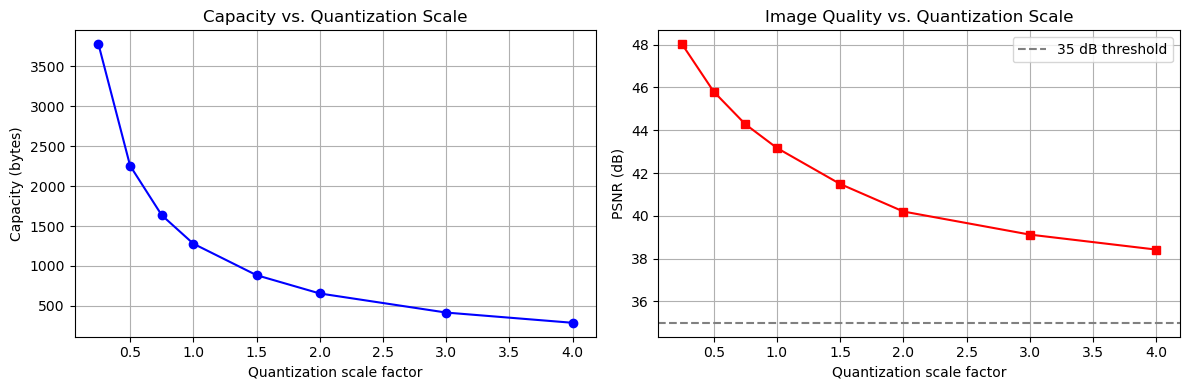

Scale | Capacity (bytes) | PSNR (dB)
------------------------------------------
 0.25 |             3775 | 48.02
 0.50 |             2255 | 45.80
 0.75 |             1636 | 44.28
 1.00 |             1279 | 43.17
 1.50 |              885 | 41.49
 2.00 |              656 | 40.20
 3.00 |              417 | 39.12
 4.00 |              289 | 38.42


In [46]:
STANDARD_QUANT = np.array([
    16, 11, 10, 16, 24, 40, 51, 61,
    12, 12, 14, 19, 26, 58, 60, 55,
    14, 13, 16, 24, 40, 57, 69, 56,
    14, 17, 22, 29, 51, 87, 80, 62,
    18, 22, 37, 56, 68, 109, 103, 77,
    24, 35, 55, 64, 81, 104, 113, 92,
    49, 64, 78, 87, 103, 121, 120, 101,
    72, 92, 95, 98, 112, 100, 103, 99
]).reshape(8, 8)

scales = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]
capacities, psnrs = [], []

with open('msg.txt') as f:
    msg_full = f.read()

for s in scales:
    qt = np.clip(np.round(STANDARD_QUANT * s).astype(np.int32), 1, 255)
    cap = capacity('cover.bmp', qt)
    capacities.append(cap)
    
    # All intermediate data stays in memory — no temp files written
    clean_bytes = _compress_to_bytes('cover.bmp', qt)
    max_chars = min(len(msg_full), (cap - 1) // 8)
    if max_chars > 0:
        stego_bytes = _embed_to_bytes(msg_full[:max_chars], 'cover.bmp', qt)
        psnrs.append(_psnr_from_bytes(clean_bytes, stego_bytes))
    else:
        psnrs.append(float('nan'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(scales, [c // 8 for c in capacities], 'bo-')
ax1.set_xlabel('Quantization scale factor')
ax1.set_ylabel('Capacity (bytes)')
ax1.set_title('Capacity vs. Quantization Scale')
ax1.grid(True)

valid = [(s, p) for s, p in zip(scales, psnrs) if not np.isnan(p)]
if valid:
    ax2.plot([v[0] for v in valid], [v[1] for v in valid], 'rs-')
    
ax2.axhline(35, color='gray', linestyle='--', label='35 dB threshold')
ax2.set_xlabel('Quantization scale factor')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Image Quality vs. Quantization Scale')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

print('Scale | Capacity (bytes) | PSNR (dB)')
print('-' * 42)
for s, c, p in zip(scales, capacities, psnrs):
    print(f' {s:4.2f} | {c//8:16d} | {p:.2f}' if not np.isnan(p) else f' {s:4.2f} | {c//8:16d} | N/A')

**Observation:** Lower scale → more non-zero quantized coefficients $\rightarrow$ higher capacity, but also more aggressive quantization error visible as blocking artifacts. PSNR decreases as scale increases (fewer embedding positions, but also less aggressive quantization $\rightarrow$ less distortion from embedding).

**Question** Based on the plots above, describe the relationship between quantization scale, embedding capacity, and PSNR. At what scale factor does the quality fall below the 35 dB perceptibility threshold?


**Answer:** 
- With low quantization scale, the embedding capacity is high because more cofficients remain non-zero after quantization, allowing more bits to be embedded. However, embedding more data introduces additional distortion, which may lead to visible artifacts.
- With high quantization scale, the embedding capacity decreases because more coefficients become zero after quantization, reducing the number of eligible coefficients for embedding. The PSNR also decreases because larger quantization steps introduce larger rounding errors.
- Note that PSNR is generally more influenced by quantization than embedding. Quantization introduces larger coefficient changes that propagate to pixel-level distortion, significantly increasing MSE. In contrast, LSB embedding only causes small ±1 modifications to a subset of coefficients, resulting in a relatively minor contribution to MSE - unless the embedding payload is very high.
- From the table, the PSNR values range from 48.02 dB to 38.42 dB, which are all above 35 dB. Therefore, the image quality never falls below the 35 dB perceptibility threshold within the tested scale range (0.25 to 4.00). If we continue increasing the scale factor beyond 4, the PSNR will likely drop below 35dB.

---
## Part 4 — Multi-bit LSB Embedding, k ∈ {1, 2, 3}

**Points:** `embed_k` **(1.5 points)** — `extract_k` **(1 point)**

### Key design choice
For k-bit embedding, a coefficient is eligible only if `|coef| >= 2^k`. This guarantees:
- After clearing the k LSBs of the magnitude: `mag & ~((1<<k)-1) >= 2^k - (2^k - 1) = 1 > 0`  
  Actually: `mag >= 2^k` → `mag & ~mask >= 2^k - (2^k-1) = 1`.  
  More precisely: the k-bit-cleared value = `(mag >> k) << k`. Since `mag >= 2^k`, `mag >> k >= 1`, so `(mag>>k) << k >= 2^k > 0`.
- The coefficient remains non-zero regardless of what k bits are written.

---

**Your task - `embed_k(...)`:** Generalize `embed()` to embed **k bits** per eligible AC coefficient.

Key differences from `embed()`:
- **Eligibility threshold:** `|coef| >= 2^k` (instead of `>= 2`).
- **Capacity:** Each eligible coefficient contributes **k** bits.
- **Bit replacement:** Replace the **k least significant bits** of the magnitude:
  ```python
  mask = (2**k) - 1                               # e.g. k=2 → mask=0b11
  chunk = int(msg_bits[bit_idx : bit_idx+k], 2)   # read k bits as integer
  mag = (abs(coef) & ~mask) | chunk               # clear k LSBs, set new bits
  ```
- Preserve the sign of the original coefficient.

**Your task - `extract_k(...)`:** Generalize `extract()` to read **k bits** per eligible coefficient.

Key differences from `extract()`:
- Same eligibility: `|coef| >= 2^k`.
- Extract k LSBs: `chunk = abs(coef) & mask`, then convert to a k-bit binary string with `bin(chunk)[2:].zfill(k)`.
- Stop marker logic is the same (find last `'1'`).

In [47]:
def embed_k(msg_file, cover_img_file, quant_table, stego_img_file, k=1):
    """
    Embed a secret message using k-bit LSB steganography in the JPEG DCT domain.

    k bits are embedded per eligible AC coefficient (|coef| >= 2^k).

    Args:
        msg_file (str):           Path to the secret message.
        cover_img_file (str):     Path to the cover image.
        quant_table (np.ndarray): 8 x 8 quantization table.
        stego_img_file (str):     Output path for the stego JPEG.
        k (int):                  Bits per coefficient: 1, 2, or 3.
    Returns:
        bool: True on success, False if message is too large.
    """
    # YOUR CODE HERE
    pixels = np.array(Image.open(cover_img_file))
    height, width = pixels.shape
    if height % 8 != 0 or width % 8 != 0:
        return False
    
    threshold = 2**k
    mask = threshold - 1
    
    with open(msg_file, 'r') as f:
        msg = f.read()
    msg_bits = tobits(msg) + '1'
    
    capacity = 0
    zzs = []
    for row in range(0, height, 8):
        for col in range(0, width, 8):
            block = pixels[row:row+8, col:col+8].astype(np.float64) - 128.0
            qc = np.round(do_dct(block) / quant_table).astype(np.int32)
            zz_coefs = qc.reshape(-1)[_ZZ]
            zzs.append(zz_coefs)
            eligible = np.sum(np.abs(zz_coefs[1:]) >= 2**k)
            capacity += eligible * k
            
    if capacity < len(msg_bits):
        return False
    
    msg_bits = msg_bits + (capacity - len(msg_bits)) * '0'
    
    # Embed
    jpeg_bytes = bytearray()
    jpeg_bytes.extend(get_header(height, width, quant_table))
    huf = Huffman()
    
    bit_idx = 0
    for zz_coefs in zzs:
        zz_coefs = zz_coefs.copy()
        for i in range(1, 64):
            c = int(zz_coefs[i])
            if abs(c) >= threshold:
                chunk = int(msg_bits[bit_idx:bit_idx+k], 2)
                bit_idx += k
                mag = (abs(c) & ~mask) | chunk
                zz_coefs[i] = mag if c > 0 else -mag
                
        nz = np.nonzero(zz_coefs)[0]
        length = int(nz[-1]) + 1 if len(nz) > 0 else 0
        huf.encode_block(zz_coefs, length)
        
    jpeg_bytes.extend(huf.end_and_get_buffer())
    jpeg_bytes.extend(struct.pack('>H', 0xFFD9))
    
    with open(stego_img_file, 'wb') as f:
        f.write(jpeg_bytes)
        
    return True
    

In [48]:
def extract_k(stego_img_file, extr_msg_file, k=1):
    """
    Extract a message hidden with k-bit LSB embedding.

    Args:
        stego_img_file (str):  Path to the stego JPEG.
        extr_msg_file  (str):  Path to write the extracted message.
        k (int):               Number of LSBs used during embedding.
    """
    # YOUR CODE HERE
    threshold = 2**k
    mask = threshold - 1
    
    all_quant_dct_coefs, _ = jpeg_decoder.get_quant_dct_coefs_and_quant_table(stego_img_file)
    all_quant_dct_coefs = np.array(all_quant_dct_coefs).reshape(-1, 64)
    
    extr_bits = ''
    for blk_natural in all_quant_dct_coefs:
        blk_zz = blk_natural[_ZZ]
        for i in range(1, 64):
            c = int(blk_zz[i])
            if abs(c) >= threshold:
                chunk = abs(c) & mask
                extr_bits += bin(chunk)[2:].zfill(k)
                
    marker_position = extr_bits.rfind('1')
    msg_bits = extr_bits[:marker_position]
    
    extr_msg = frombits(msg_bits)
    with open(extr_msg_file, 'w') as f:
        f.write(extr_msg)

In [49]:
# TEST
with open('msg.txt') as f:
    expected = f.read()

for k in (1, 2, 3):
    embed_k('msg.txt', 'cover.bmp', quant_table, f'stego_k{k}.jpg', k=k)
    extract_k(f'stego_k{k}.jpg', f'extr_k{k}.txt', k=k)
    with open(f'extr_k{k}.txt') as f:
        got = f.read()
    assert got == expected, f'k={k} round-trip failed'
    print(f'k={k} round-trip: OK')

k=1 round-trip: OK
k=2 round-trip: OK
k=3 round-trip: OK


### 4.2 Capacity and PSNR vs. k

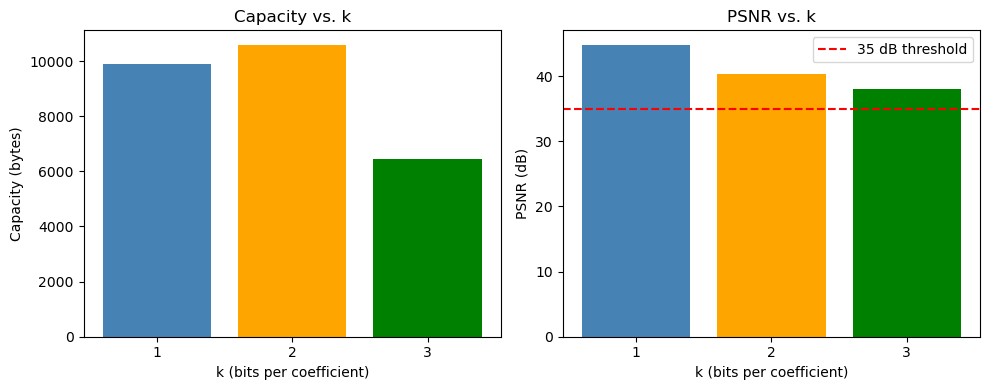

k | Capacity (bytes) | PSNR (dB)
--------------------------------------
1 |             9879 | 44.80
2 |            10588 | 40.36
3 |             6455 | 37.96


In [50]:
ks = [1, 2, 3]
cap_k, psnr_k = [], []

with open('msg.txt') as f:
    msg_full = f.read()
    
clean_bytes = _compress_to_bytes('cover.bmp', quant_table)

for k in ks:
    cap_k.append(capacity('cover.bmp', quant_table, k=k))
    stego_bytes = _embed_to_bytes(msg_full, 'cover.bmp', quant_table, k=k)
    psnr_k.append(_psnr_from_bytes(clean_bytes, stego_bytes))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
colors = ['steelblue', 'orange', 'green']
ax1.bar([str(k) for k in ks], [c // 8 for c in cap_k], color=colors)
ax1.set_xlabel('k (bits per coefficient)')
ax1.set_ylabel('Capacity (bytes)')
ax1.set_title('Capacity vs. k')

ax2.bar([str(k) for k in ks], psnr_k, color=colors)
ax2.axhline(35, color='red', linestyle='--', label='35 dB threshold')
ax2.set_xlabel('k (bits per coefficient)')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('PSNR vs. k')
ax2.legend()
plt.tight_layout()
plt.show()

print('k | Capacity (bytes) | PSNR (dB)')
print('-' * 38)
for k, c, p in zip(ks, cap_k, psnr_k):
    print(f'{k} | {c//8:16d} | {p:.2f}')

**Question** Does PSNR drop significantly between $k=1$ and $k=3$? Explain why increasing $k$ causes larger coefficient modifications and thus more distortion.

**Answer:** 
- Yes, PSNR drops significantly as k increases from 1 to 3. 
- This is because increasing k allows more bits to be embedded per coefficient, which means the magnitude of changes to the coefficients can be larger. For k=1, the maximum change is ±1; for k=2 it is ±3; for k=3 it is ±7. After multiplying back through the quantization table during decoding, these errors scale proportionally, causing larger pixel-domain distortion.
- Additionally, capacity does not increase linearly with k: k=2 yields 10,588 bytes (only slightly more than k=1's 9,879 bytes) because the stricter eligibility threshold (|coef| ≥ 4 for k=2) excludes many small coefficients. At k=3 the threshold rises to |coef| ≥ 8, cutting capacity to 6,455 bytes — less than k=1 — while still causing the largest distortion. Therefore k=1 offers the best capacity-to-distortion trade-off for this image and quantization table.

---
## Part 5 — Adaptive Embedding

### Design principle and stable texture metric

We restrict embedding to **textured blocks** — those with many eligible AC coefficients — to avoid modifying perceptually sensitive smooth regions.

The texture score for a block is the **count of eligible AC coefficients** (`|coef| >= 2`). This is perfectly stable across embedding: every eligible coef (magnitude ≥ 2) stays eligible after embedding because we only flip the LSB of the magnitude — the magnitude can only go from 2 $\rightarrow$ 2, 2 $\rightarrow$ 3, 3 $\rightarrow$ 2, 3 $\rightarrow$ 3, etc., never below 2. Therefore the extractor can use the exact same metric on the stego coefs and always identify the same blocks.

### 5.1 Block Texture Measure — `block_texture_score` (0.5 point)

**Your task:** Compute a texture score for a single $8 \times 8$ pixel block.

**Steps:**
1. Level-shift the block (subtract 128), apply DCT, quantize, reorder to zig-zag.
2. Count the number of AC coefficients (indices 1–63) with `|coef| >= 2`.
3. Return that count (an integer from 0 to 63).

*Why this metric?* Blocks with more large AC coefficients have more high-frequency detail (texture). Embedding changes in textured regions are less visible to the human eye.

In [51]:
def block_texture_score(block_pixels, quant_table):
    """
    Compute the texture score of an 8 x 8 block.

    Score = number of AC coefficients with |quantized value| >= 2.
    This metric is invariant to 1-bit LSB embedding (eligible coefs stay eligible).

    Args:
        block_pixels (np.ndarray): 8 x 8 pixel block.
        quant_table (np.ndarray):  8 x 8 quantization table.
    Returns:
        int: Texture score (0–63).
    """
    # YOUR CODE HERE
    block = block_pixels.astype(np.float64) - 128.0
    qc = np.round(do_dct(block) / quant_table).astype(np.int32)
    zz_coefs = qc.reshape(-1)[_ZZ]
    return np.sum(np.abs(zz_coefs[1:]) >= 2)

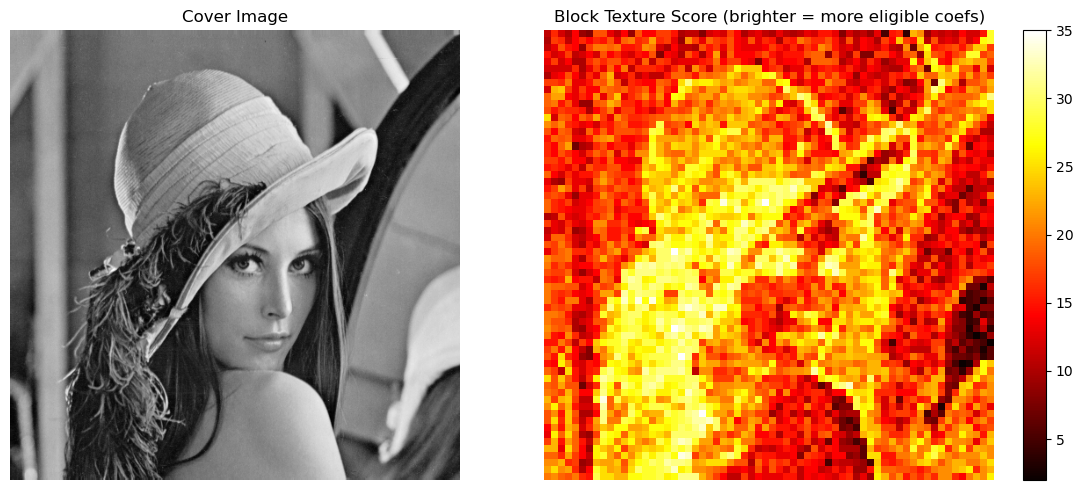

Score range: [2, 35]  Median: 19


In [52]:
# Visualize texture map
cover_pixels = np.array(Image.open('cover.bmp'))
height, width = cover_pixels.shape
n_bh, n_bw = height // 8, width // 8

texture_map = np.zeros((n_bh, n_bw))
for r in range(n_bh):
    for c in range(n_bw):
        texture_map[r, c] = block_texture_score(
            cover_pixels[r*8:(r+1)*8, c*8:(c+1)*8], quant_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cover_pixels, cmap='gray')
axes[0].set_title('Cover Image')
axes[0].axis('off')
im = axes[1].imshow(texture_map, cmap='hot', interpolation='nearest')
axes[1].set_title('Block Texture Score (brighter = more eligible coefs)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(f'Score range: [{texture_map.min():.0f}, {texture_map.max():.0f}]  Median: {np.median(texture_map):.0f}')

### 5.2 Implement `embed_adaptive` and `extract_adaptive`

**Points:** `embed_adaptive` **(1 point)** — `extract_adaptive` **(0.5 point)**

---

**Your task - `embed_adaptive(...)`:** Modify `embed()` so that only **textured blocks** are used for embedding.

**Steps:**
1. Compute `block_texture_score()` for every $8 \times 8$ block in the image.
2. If `T` is `None`, set it to the **median** of all scores.
3. **Capacity** = sum of scores for blocks where `score > T` (since score = number of eligible coefs in that block).
4. Same message preparation: `tobits(msg) + '1'` + zero-padding to capacity.
5. During the block loop: if `score > T`, embed into eligible AC coefs (same LSB logic as `embed()`). If `score <= T`, encode the block **without any modification**.
6. Return `(True, T)` on success or `(False, T)` if message too large.

**Your task - `extract_adaptive(...)`:** Extract from only the textured blocks.

**Steps:**
1. Decode the stego JPEG to get all quantized DCT coefficients.
2. For each block, reorder to zig-zag and compute its texture score from the stego coefficients.
3. If `score > T`, extract LSBs from eligible AC coefficients in that block. Otherwise skip.
4. Find the stop marker and recover the message as before.

*Key insight:* The texture score is **invariant to embedding** — eligible coefs (|coef| >= 2) remain eligible after LSB modification, so the extractor computes the exact same scores as the embedder.

In [53]:
def embed_adaptive(msg_file, cover_img_file, quant_table, stego_img_file, T=None):
    """
    Embed a secret message using adaptive LSB steganography.

    Only 8 x 8 blocks whose texture score (count of |coef| >= 2 AC coefs)
    exceeds threshold T are used for embedding.

    T defaults to the median texture score across all blocks.

    The texture score is invariant to embedding, so the extractor can reproduce
    the exact same block selection by computing scores from the stego coefs.

    Args:
        msg_file (str):           Path to the secret message file.
        cover_img_file (str):     Path to the cover image.
        quant_table (np.ndarray): 8 x 8 quantization table.
        stego_img_file (str):     Output path for the stego JPEG.
        T (float or None):        Texture threshold. None = use median.
    Returns:
        tuple: (bool success, float T_used)
    """
    # YOUR CODE HERE
    pixels = np.array(Image.open(cover_img_file))
    height, width = pixels.shape
    
    with open(msg_file, 'r') as f:
        msg = f.read()
    msg_bits = tobits(msg) + '1'
    
    scores = []
    zzs = []
    for row in range(0, height, 8):
        for col in range(0, width, 8):
            score = block_texture_score(pixels[row:row+8, col:col+8], quant_table)
            scores.append(score)
            block = pixels[row:row+8, col:col+8].astype(np.float64) - 128.0
            qc = np.round(do_dct(block) / quant_table).astype(np.int32)
            zz_coefs = qc.reshape(-1)[_ZZ]
            zzs.append(zz_coefs)
            
    if T is None:
        T = float(np.median(scores))
        
    capacity = sum(s for s in scores if s > T)
    if capacity < len(msg_bits):
        return (False, T)
    
    # Padding
    msg_bits = msg_bits + (capacity - len(msg_bits)) * '0'
    
    # Embed
    jpeg_bytes = bytearray()
    jpeg_bytes.extend(get_header(height, width, quant_table))
    huf = Huffman()
    
    bit_idx = 0
    for zz_coefs, score in zip(zzs, scores):
        zz_coefs = zz_coefs.copy()
        if score > T:
            for i in range(1, 64):
                c = int(zz_coefs[i])
                if abs(c) >= 2:
                    b = int(msg_bits[bit_idx])
                    bit_idx += 1
                    if c > 0:
                        c = (c & ~1) | b
                    else:
                        c = -((-c & ~1) | b)
                    zz_coefs[i] = c

        nz = np.nonzero(zz_coefs)[0]
        length = int(nz[-1]) + 1 if len(nz) > 0 else 0
        huf.encode_block(zz_coefs, length)

    jpeg_bytes.extend(huf.end_and_get_buffer())
    jpeg_bytes.extend(struct.pack(">H", 0xFFD9))

    with open(stego_img_file, 'wb') as f:
        f.write(jpeg_bytes)

    return (True, T)
    

In [54]:
def extract_adaptive(stego_img_file, extr_msg_file, T):
    """
    Extract a message hidden with adaptive embedding.

    Reproduces block selection by computing texture scores from the stego coefs.
    Because the texture metric (count of |coef| >= 2) is invariant to embedding,
    the same T identifies exactly the same blocks.

    Args:
        stego_img_file (str):  Path to the stego JPEG.
        extr_msg_file  (str):  Path to write the extracted message.
        T (float):             Texture threshold used during embedding.
    """
    # YOUR CODE HERE
    all_quant_dct_coefs, _ = jpeg_decoder.get_quant_dct_coefs_and_quant_table(stego_img_file)
    all_quant_dct_coefs = np.array(all_quant_dct_coefs).reshape(-1, 64)
    
    extr_bits = ''
    for blk_natural in all_quant_dct_coefs:
        blk_zz = blk_natural[_ZZ]
        score = np.sum(np.abs(blk_zz[1:]) >= 2)
        if score > T:
            for i in range(1, 64):
                c = int(blk_zz[i])
                if abs(c) >= 2:
                    extr_bits += str(abs(c) & 1)
                
    marker_position = extr_bits.rfind('1')
    msg_bits = extr_bits[:marker_position]
    
    extr_msg = frombits(msg_bits)
    with open(extr_msg_file, 'w') as f:
        f.write(extr_msg)

In [55]:
# TEST
success, T_used = embed_adaptive(
    'msg.txt', 'cover.bmp', quant_table, 'stego_adaptive.jpg')
assert success == True, 'embed_adaptive failed'
print(f'T used: {T_used}')

extract_adaptive('stego_adaptive.jpg', 'extr_adaptive.txt', T_used)

with open('extr_adaptive.txt') as f:
    got = f.read()
with open('msg.txt') as f:
    expected = f.read()
    
assert got == expected, 'Adaptive round-trip failed'
print('embed_adaptive / extract_adaptive: OK')

T used: 19.0
embed_adaptive / extract_adaptive: OK


### 5.3 Compare Standard vs. Adaptive Embedding

Method        | Capacity (bytes) | PSNR (dB)
----------------------------------------------
Standard (k=1)|             9879 | 44.80
Adaptive      |             5843 | 45.51


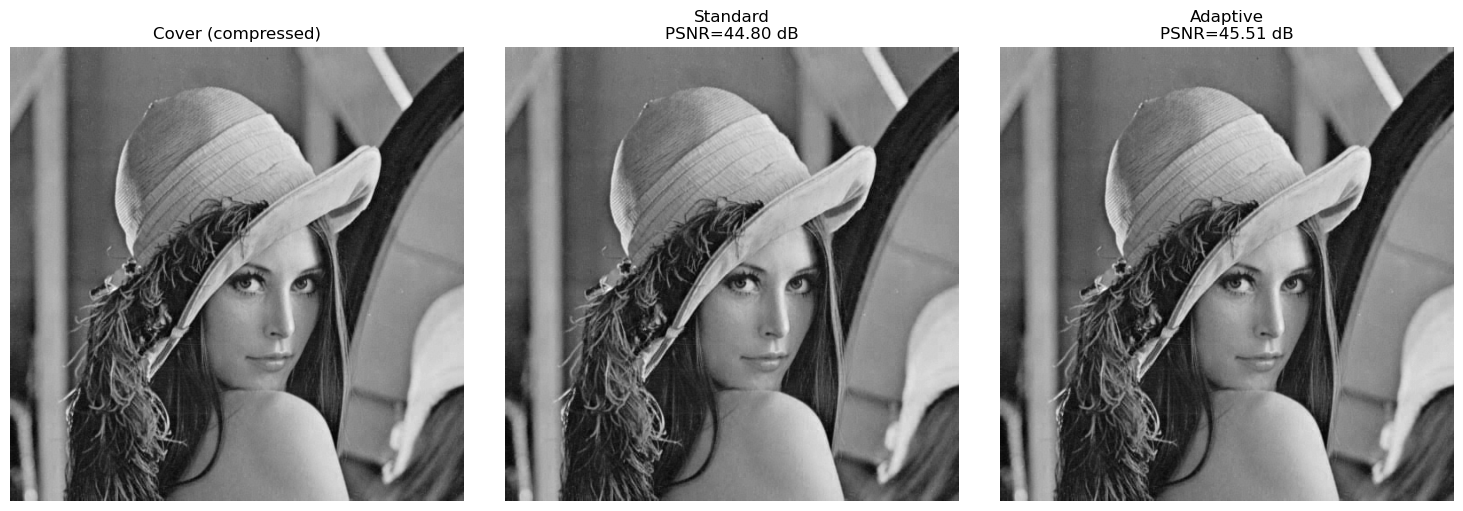

In [56]:
with open('msg.txt') as f:
    msg_full = f.read()

clean_bytes = _compress_to_bytes('cover.bmp', quant_table)
std_bytes = _embed_to_bytes(msg_full, 'cover.bmp', quant_table, k=1)
success, T_used = embed_adaptive(
    'msg.txt', 'cover.bmp', quant_table, 'stego_adaptive.jpg')

psnr_std = _psnr_from_bytes(clean_bytes, std_bytes)
psnr_adap = compute_psnr('cover_compressed.jpg',
                         'stego_adaptive.jpg')  # reuse existing file

cap_std = capacity('cover.bmp', quant_table) // 8
cover_px = np.array(Image.open('cover.bmp'))
h_px, w_px = cover_px.shape
cap_adap = sum(
    block_texture_score(cover_px[r:r+8, c:c+8], quant_table)
    for r in range(0, h_px, 8)
    for c in range(0, w_px, 8)
    if block_texture_score(cover_px[r:r+8, c:c+8], quant_table) > T_used
) // 8

print(f'Method        | Capacity (bytes) | PSNR (dB)')
print('-' * 46)
print(f'Standard (k=1)| {cap_std:16d} | {psnr_std:.2f}')
print(f'Adaptive      | {cap_adap:16d} | {psnr_adap:.2f}')

# Visual comparison uses in-memory images decoded from bytes
clean_img = np.array(Image.open(io.BytesIO(clean_bytes)))
std_img = np.array(Image.open(io.BytesIO(std_bytes)))
adap_img = np.array(Image.open('stego_adaptive.jpg'))  # written by embed_adaptive

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(clean_img,  cmap='gray')
axes[0].set_title('Cover (compressed)')
axes[0].axis('off')
axes[1].imshow(std_img,    cmap='gray')
axes[1].set_title(f'Standard\nPSNR={psnr_std:.2f} dB')
axes[1].axis('off')
axes[2].imshow(adap_img,   cmap='gray')
axes[2].set_title(f'Adaptive\nPSNR={psnr_adap:.2f} dB')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### 5.4 Threshold Sensitivity Analysis

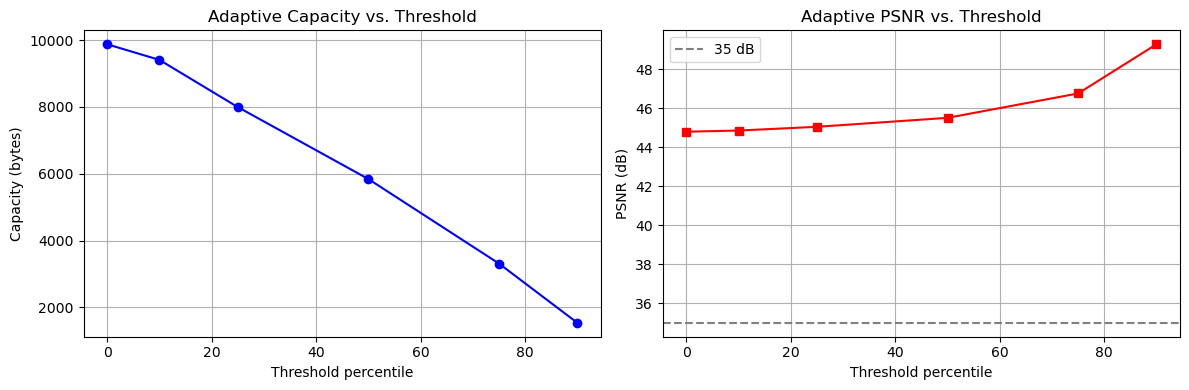

Percentile | T     | Capacity (bytes) | PSNR (dB)
-------------------------------------------------------
         0 |     2 |             9878 | 44.80
        10 |    11 |             9410 | 44.85
        25 |    15 |             7998 | 45.05
        50 |    19 |             5843 | 45.51
        75 |    24 |             3313 | 46.76
        90 |    28 |             1539 | 49.28


In [57]:
cover_px = np.array(Image.open('cover.bmp'))
h_px, w_px = cover_px.shape

all_scores = [
    block_texture_score(cover_px[r:r+8, c:c+8], quant_table)
    for r in range(0, h_px, 8)
    for c in range(0, w_px, 8)
]

percentiles = [0, 10, 25, 50, 75, 90]
thresholds = [float(np.percentile(all_scores, p)) for p in percentiles]
adapt_caps, adapt_psnrs = [], []

clean_bytes = _compress_to_bytes('cover.bmp', quant_table)
with open('msg.txt') as f:
    msg_full = f.read()

for T in thresholds:
    cap = sum(s for s in all_scores if s > T)
    adapt_caps.append(cap // 8)
    # Embed in-memory: no temp file
    stego_bytes = _embed_adaptive_to_bytes(
        msg_full, 'cover.bmp', quant_table, T)
    adapt_psnrs.append(_psnr_from_bytes(
        clean_bytes, stego_bytes) if stego_bytes else float('nan'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(percentiles, adapt_caps, 'bo-')
ax1.set_xlabel('Threshold percentile')
ax1.set_ylabel('Capacity (bytes)')
ax1.set_title('Adaptive Capacity vs. Threshold')
ax1.grid(True)

valid = [(p, v) for p, v in zip(percentiles, adapt_psnrs) if not np.isnan(v)]
if valid:
    ax2.plot([v[0] for v in valid], [v[1] for v in valid], 'rs-')
    
ax2.axhline(35, color='gray', linestyle='--', label='35 dB')
ax2.set_xlabel('Threshold percentile')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Adaptive PSNR vs. Threshold')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

print('Percentile | T     | Capacity (bytes) | PSNR (dB)')
print('-' * 55)
for pct, T, cap, p in zip(percentiles, thresholds, adapt_caps, adapt_psnrs):
    ps = f'{p:.2f}' if not np.isnan(p) else 'N/A (no capacity)'
    print(f'{pct:10d} | {T:5.0f} | {cap:16d} | {ps}')

**Question** As the threshold percentile increases (fewer blocks used), how do capacity and PSNR change? Is there a "sweet spot" where PSNR is significantly improved with only modest capacity loss?

**Answer:**
| Percentile | T  | Capacity (bytes) | PSNR (dB) | % Capacity vs baseline | PSNR improvement vs baseline |
|---|---|---|---|---|---|
| 0  | 2  | 9878 | 44.80 | 0% | 0 dB |
| 10 | 11 | 9410 | 44.85 | -4.7% | +0.05 dB |
| 25 | 15 | 7998 | 45.05 | -19.0% | +0.25 dB |
| 50 | 19 | 5843 | 45.51 | -40.7% | +0.71 dB |
| 75 | 24 | 3313 | 46.76 | -66.4% | +1.96 dB |
| 90 | 28 | 1539 | 49.28 | -84.3% | +4.48 dB |

- As the threshold percentile increases, capacity decreases and PSNR increases. This is because fewer blocks are selected for embedding, and only the most textured blocks (with the highest counts of eligible AC coefficients) are used for embedding. These blocks can hide changes more effectively, resulting in less visible distortion and higher PSNR.
- The results do not exhibit a clear "sweet spot", but rather a continuous trade-off between capacity and visual quality. However, the 50%–75% percentile range provides a practical operating region where PSNR improvement becomes perceptually meaningful while retaining a usable embedding capacity.